<a href="https://colab.research.google.com/github/mrAlimovich/computer_vision1/blob/main/pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
pip install torch

In [4]:
import torch

In [5]:
print(torch.__version__)

2.11.0+cu128


In [6]:
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [7]:
scolar = torch.tensor(5) #0D
print('scolar:', scolar)
print('Shape:', scolar.shape)
print('Size:', scolar.size())

scolar: tensor(5)
Shape: torch.Size([])
Size: torch.Size([])


In [8]:
vector = torch.tensor([1, 2, 3]) # 1D
print("vector:", vector)
print('Shape:', vector.shape)
print('Number of Dimensions:', scolar.ndim)
print('Size:', vector.size())

vector: tensor([1, 2, 3])
Shape: torch.Size([3])
Number of Dimensions: 0
Size: torch.Size([3])


In [9]:
MATRIX = torch.tensor([[1, 2, 3],
                       [4, 5, 6]]) # 2D
print('MATRIX:', MATRIX)
print('MATRIX:', MATRIX.shape)
print('Number of Dimensions:', MATRIX.ndim)

MATRIX: tensor([[1, 2, 3],
        [4, 5, 6]])
MATRIX: torch.Size([2, 3])
Number of Dimensions: 2


In [10]:
tensor3d = torch.stack([MATRIX, MATRIX + 10]) # 3D
print('tensor3d:', tensor3d)
print('Shape:', tensor3d.shape) # [2, 2, 3] | 2 matrices => channels | 2 rows in each matrix | 3 columns in each matrix (height, width) [C, H, W]
print('Number of Dimensions:', tensor3d.ndim)

tensor3d: tensor([[[ 1,  2,  3],
         [ 4,  5,  6]],

        [[11, 12, 13],
         [14, 15, 16]]])
Shape: torch.Size([2, 2, 3])
Number of Dimensions: 3


In [11]:
random_numbers = torch.rand(2, 3) # 0~1
print('Rabdom Numbers:', random_numbers)
print('Data type:', random_numbers.dtype)
print('Device of random_numbers:', random_numbers.device)

Rabdom Numbers: tensor([[0.9992, 0.2813, 0.9889],
        [0.9407, 0.7187, 0.9234]])
Data type: torch.float32
Device of random_numbers: cpu


In [12]:
print('Zero:', torch.zeros(3, 3))

Zero: tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]])


In [13]:
print('Ones:', torch.ones(2, 4))

Ones: tensor([[1., 1., 1., 1.],
        [1., 1., 1., 1.]])


In [14]:
x = torch.tensor([[1, 2],
                 [3, 4]])
y = torch.tensor([[5, 6],
                  [7, 8]])
# Element-wise addition
print('Addirion:', x + y)
print('====================')

# Eliment-wise multipication
print('Multipication:', x * y)
print('====================')

# Martix Multipication
print("Matrix @ multipication:", x @ y)


# x
# [[1, 2],
#  [3, 4]]

# # y
# [[5, 6],
#  [7, 8]]


Addirion: tensor([[ 6,  8],
        [10, 12]])
Multipication: tensor([[ 5, 12],
        [21, 32]])
Matrix @ multipication: tensor([[19, 22],
        [43, 50]])


# [1, 2] * [5, 7] = 1 * 5 + 2 * 7 = 5 + 14 = 19
# [1, 2] * [6, 8] = 1 * 6 + 2 * 8 = 6 + 16 = 22
# [3, 4] * [5, 7] = 3 * 5 + 4 * 7 = 15 + 28 = 43
# [3, 4] * [6, 8] = 3 * 8 + 4 * 8 = 28 + 32 = 50


In [15]:
 # Import PyTorch and matplotlib
 import torch
 from torch import nn # nn contains all of PyTorch's building blocks for neural networks | nn module
 import matplotlib.pyplot as plt

 # Check PyTorch version
 torch.__version__

'2.11.0+cu128'

In [16]:
# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device:{device}")

# CNN
# NN

Using device:cuda


In [17]:
# Create weight and bias
weight = 0.7 # Weight
bias = 0.3 # bias

# Create range values
start = 0 # 0 dan boshlansin
end = 1 # yakuni 1
step = 0.02 # 0.02 qadam oraligida bolsin

# Create X and y (features and labels)
X = torch.arange(start, end, step).unsqueeze(dim=1)  # without unsqueeze, errors will happen later on (shapes within linear layers)
y = weight * X + bias

# Liner Regrssion: y = wx + b
# print("X:", X)

# print("\n y:", y)

# Split data
train_split = int(0.8 * len(X)) # 10000 (100%) data => 8000 (80%) train | 2000(20%) test
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

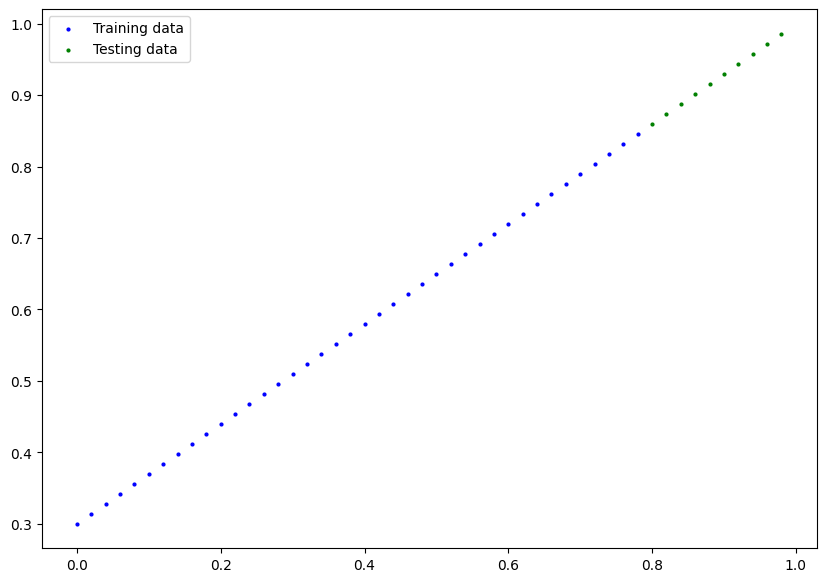

In [18]:
def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    plt.figure(figsize=(10, 7))

    # Plot training data in blue
    plt.scatter(train_data, train_labels, c='b', s=4, label='Training data')

    # Plot test data in green
    plt.scatter(test_data, test_labels, c='g', s=4, label='Testing data')

    if predictions is not None:
        plt.scatter(test_data, predictions, c='r', s=4, label='Predictions')

    plt.legend(prop={'size': 10})

plot_predictions()

In [19]:
# Subclass nn.Module to make our model
class LinearRegressionModelV2(nn.Module):
    def __init__(self):
        super().__init__()
        # Use nn.Linear() for creating the model parameters
        self.linear_layer = nn.Linear(in_features=1,# weight and bias
                                      out_features=1) # Liner => y = wx+b

    # Define the forward computation (input data x flows through nn.Linear())
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

# Set the manual seed when creating the model (this isn't always needed but is used for demonstrative purposes, try commenting it out and seeing what happens)
torch.manual_seed(42)
model_1 = LinearRegressionModelV2()
model_1, model_1.state_dict()

(LinearRegressionModelV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [20]:
# Create loss function
loss_fn = nn.L1Loss() # loss Function | MAE => Mean Absolute Error

# Create optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(),  # optimize newly created model's parameters
                             lr=0.01) # weight and bias | equal

Text(0.5, 1.0, 'Predictions before training (red = random guesses)')

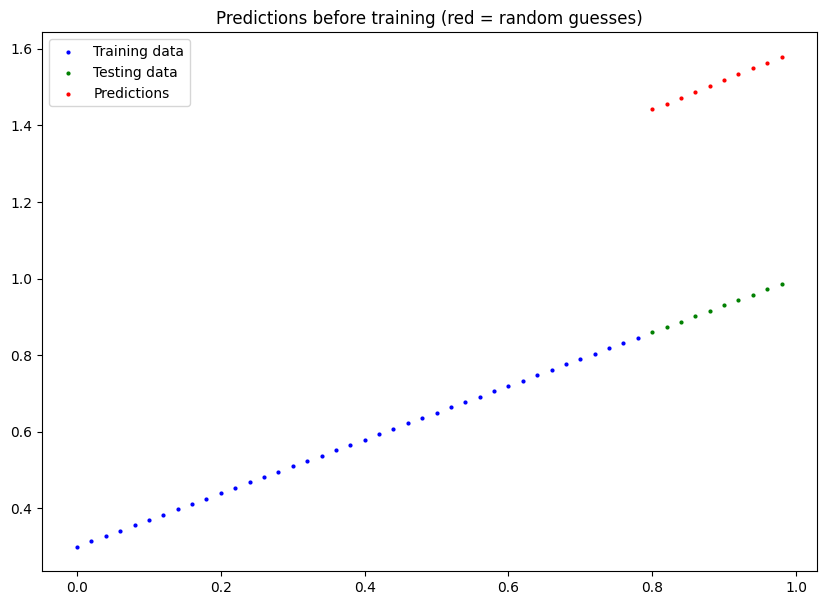

In [21]:
# See model's untrained predictions (on test set)
model_1.eval() #
with torch.inference_mode():
    y_preds_early = model_1(X_test) # backwards

plot_predictions(predictions=y_preds_early)
plt.title("Predictions before training (red = random guesses)")

In [25]:
# Set the number of epochs
epochs = 1000

# Put data on the available device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

# Put model on the available device
model_1 = model_1.to(device)

for epoch in range(epochs):
    ### Training
    model_1.train()

    # 1. Forward pass
    y_pred = model_1(X_train)

    # 2. Calculate loss
    loss = loss_fn(y_pred, y_train)

    # 3. Zero gradient optimizer
    optimizer.zero_grad()

    # 4. Loss backward
    loss.backward()

    # 5. Step the optimizer
    optimizer.step()

    ### Testing
    model_1.eval()
    with torch.inference_mode():
        test_pred = model_1(X_test)
        test_loss = loss_fn(test_pred, y_test)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Train loss: {loss} | Test loss: {test_loss}")

Epoch: 0 | Train loss: 0.5551779270172119 | Test loss: 0.5739762187004089
Epoch: 100 | Train loss: 0.006215683650225401 | Test loss: 0.014086711220443249
Epoch: 200 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 300 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 400 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 500 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 600 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 700 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 800 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882
Epoch: 900 | Train loss: 0.0012645035749301314 | Test loss: 0.013801801018416882


In [27]:
# Turn model into evaluation mode
model_1.eval()

# Make predictions on the test data
with torch.inference_mode():
  y_preds = model_1(X_test)
y_preds

tensor([[0.8600],
        [0.8739],
        [0.8878],
        [0.9018],
        [0.9157],
        [0.9296],
        [0.9436],
        [0.9575],
        [0.9714],
        [0.9854]], device='cuda:0')

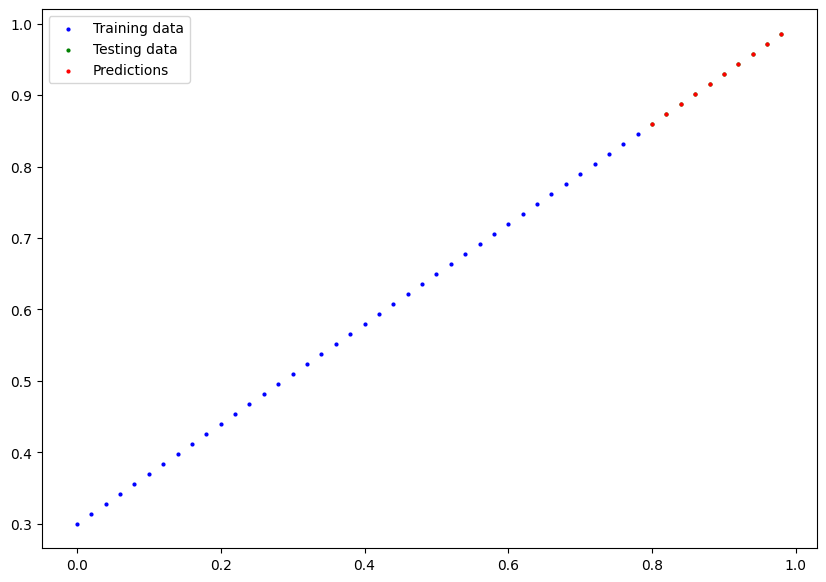

In [29]:
# Put data on the CPU and plot it
plot_predictions(predictions=y_preds.cpu())

In [33]:
torch.save(model_1.state_dict(), 'trained_model.pth')

In [34]:
loaded_model = LinearRegressionModelV2()

loaded_model.load_state_dict(torch.load('/content/trained_model.pth'))

loaded_model.eval()

LinearRegressionModelV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)